# 04 — Modélisation du modèle 2 de recommandation

Ce notebook a pour objectif de construire le **modèle secondaire** utilisé dans la recommandation lorsque la couverture du modèle principal est insuffisante.

## Positionnement du modèle 2 dans l’application

La logique de routage retenue à l’échelle du projet est la suivante :

1. utilisation de `model_1_crop` lorsque la culture dispose d’un profil enrichi exploitable ;
2. utilisation de `model_1_general` lorsque la culture appartient au dataset principal mais sans profil enrichi exploitable ;
3. utilisation de `model_2_recommendation` lorsque la culture n’est couverte que par le dataset secondaire.

Ce notebook documente donc un modèle **complémentaire**, et non un remplacement du modèle principal.

## Objectifs opérationnels

Ce notebook vise à :

- repartir du dataset annexe consolidé construit en amont ;
- effectuer les contrôles ciblés nécessaires avant modélisation ;
- comparer un **benchmark maximal** et un **modèle déployable** ;
- sélectionner le meilleur modèle secondaire compatible avec l’usage métier ;
- exporter les artefacts nécessaires à l’API et à la logique de recommandation.

## Entrées

- `data/processed/yield_dataset_consolidated.csv`

## Sorties

- `artifacts/model_2_recommendation.joblib`
- `artifacts/model_2_meta.json`

In [1]:
from pathlib import Path
import sys
import json

import joblib
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from project_paths import PROCESSED_DIR

OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except Exception:
    CATBOOST_AVAILABLE = False

SEED = 42

In [2]:
MLFLOW_DB_PATH = ROOT / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB_PATH.as_posix()}")
mlflow.set_experiment("agritech-model-2-recommendation")
print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("CatBoost available:", CATBOOST_AVAILABLE)

MLflow tracking URI: sqlite:///C:/Users/thoma/Documents/Openclassroom/Projet-12/mlflow.db
CatBoost available: True


## 1. Chargement du dataset annexe consolidé

Le dataset utilisé ici provient du notebook `01_eda_sources.ipynb`.
Il agrège plusieurs sources relatives au rendement, à la pluie, à la température et aux pesticides.

L’objectif de cette première étape est de vérifier que les colonnes attendues sont présentes avant les contrôles ciblés.

In [3]:
df = pd.read_csv(PROCESSED_DIR / "yield_dataset_consolidated.csv")
print("Shape :", df.shape)
display(df.head())

expected_columns = [
    "Area",
    "Item",
    "Year",
    "Unit",
    "hg/ha_yield",
    "pesticides_tonnes",
    "average_rain_fall_mm_per_year",
    "avg_temp",
]
missing_columns = [col for col in expected_columns if col not in df.columns]
print("Colonnes manquantes :", missing_columns)
df.dtypes

Shape : (13136, 8)


,Area,Item,Year,Unit,hg/ha_yield,pesticides_tonnes,average_rain_fall_mm_per_year,avg_temp
0,Albania,Maize,1990,hg/ha,36613,121.0,1485.0,16.37
1,Albania,Maize,1991,hg/ha,29068,121.0,1485.0,15.36
2,Albania,Maize,1992,hg/ha,24876,121.0,1485.0,16.06
3,Albania,Maize,1993,hg/ha,24185,121.0,1485.0,16.05
4,Albania,Maize,1994,hg/ha,25848,201.0,1485.0,16.96


Colonnes manquantes : []


Area                              object
Item                              object
Year                               int64
Unit                              object
hg/ha_yield                        int64
pesticides_tonnes                float64
average_rain_fall_mm_per_year    float64
avg_temp                         float64
dtype: object

## 2. Vérifications ciblées rapides

Cette étape ne refait pas l’ensemble de l’analyse exploratoire.
Elle se concentre sur les points susceptibles d’affecter directement la modélisation du modèle secondaire :

- typage des variables ;
- doublons ;
- valeurs manquantes ;
- plages de valeurs.

In [4]:
num_cols = [
    "Year",
    "hg/ha_yield",
    "pesticides_tonnes",
    "average_rain_fall_mm_per_year",
    "avg_temp",
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Doublons exacts :", int(df.duplicated().sum()))
print("Doublons Area / Item / Year :", int(df.duplicated(subset=["Area", "Item", "Year"]).sum()))

missing_report = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_count")
    .to_frame()
)
display(missing_report)

df[num_cols].describe().T

Doublons exacts : 0
Doublons Area / Item / Year : 0


,missing_count
average_rain_fall_mm_per_year,6
Area,0
Year,0
Item,0
Unit,0
hg/ha_yield,0
pesticides_tonnes,0
avg_temp,0


,count,mean,std,min,25%,50%,75%,max
Year,13136.0,2001.617692,7.035556,1990.00,1995.0000,2001.00,2008.00,2013.00
hg/ha_yield,13136.0,70959.634440,79111.427638,50.00,18000.0000,39536.00,97159.00,501412.00
pesticides_tonnes,13136.0,14832.141503,33646.165696,0.04,264.5825,2170.40,13335.22,367778.00
average_rain_fall_mm_per_year,13130.0,1157.238766,743.622488,51.00,608.0000,1083.00,1651.00,3240.00
avg_temp,13136.0,19.839209,6.657741,1.30,15.6700,20.62,25.78,30.42


## 3. Contrôles métier et nettoyage minimal

Une distinction est faite entre :

- les **valeurs impossibles** au sens métier ;
- les **valeurs extrêmes** au sens statistique.

Les valeurs impossibles sont retirées avant modélisation :

- `hg/ha_yield < 0`
- `average_rain_fall_mm_per_year < 0`
- `pesticides_tonnes < 0`

En revanche, une température négative n’est pas supprimée par principe car elle peut être réaliste selon les zones géographiques.

In [5]:
impossible_summary = {
    "yield_negatif": int((df["hg/ha_yield"] < 0).sum()),
    "rain_negatif": int((df["average_rain_fall_mm_per_year"] < 0).sum()),
    "pesticides_negatif": int((df["pesticides_tonnes"] < 0).sum()),
}
impossible_summary

{'yield_negatif': 0, 'rain_negatif': 0, 'pesticides_negatif': 0}

In [6]:
df_model = df.copy()

df_model = df_model[df_model["hg/ha_yield"] >= 0].copy()
df_model = df_model[df_model["average_rain_fall_mm_per_year"] >= 0].copy()
df_model = df_model[df_model["pesticides_tonnes"] >= 0].copy()

df_model["yield_t_ha"] = df_model["hg/ha_yield"] / 10000.0
df_model["log1p_pesticides_tonnes"] = np.log1p(df_model["pesticides_tonnes"])

model_num_cols = num_cols + ["yield_t_ha", "log1p_pesticides_tonnes"]

print("Shape après nettoyage métier :", df_model.shape)
df_model[model_num_cols].describe().T

Shape après nettoyage métier : (13130, 10)


,count,mean,std,min,25%,50%,75%,max
Year,13130.0,2001.622772,7.033139,1990.000000,1995.000000,2001.000000,2008.000000,2013.000000
hg/ha_yield,13130.0,70968.615461,79124.283809,50.000000,18000.000000,39543.500000,97152.250000,501412.000000
pesticides_tonnes,13130.0,14838.697886,33652.454670,0.040000,264.530000,2172.200000,13335.220000,367778.000000
average_rain_fall_mm_per_year,13130.0,1157.238766,743.622488,51.000000,608.000000,1083.000000,1651.000000,3240.000000
avg_temp,13130.0,19.836531,6.658083,1.300000,15.670000,20.620000,25.780000,30.420000
yield_t_ha,13130.0,7.096862,7.912428,0.005000,1.800000,3.954350,9.715225,50.141200
log1p_pesticides_tonnes,13130.0,7.474329,2.577593,0.039221,5.581728,7.683956,9.498239,12.815237


## 4. Exploration ciblée des distributions et des outliers

L’objectif n’est pas de supprimer automatiquement toutes les observations extrêmes.
Cette étape vise surtout à :

- repérer les distributions très asymétriques ;
- vérifier l’intérêt d’une transformation simple sur les pesticides ;
- quantifier les valeurs extrêmes avant la modélisation.

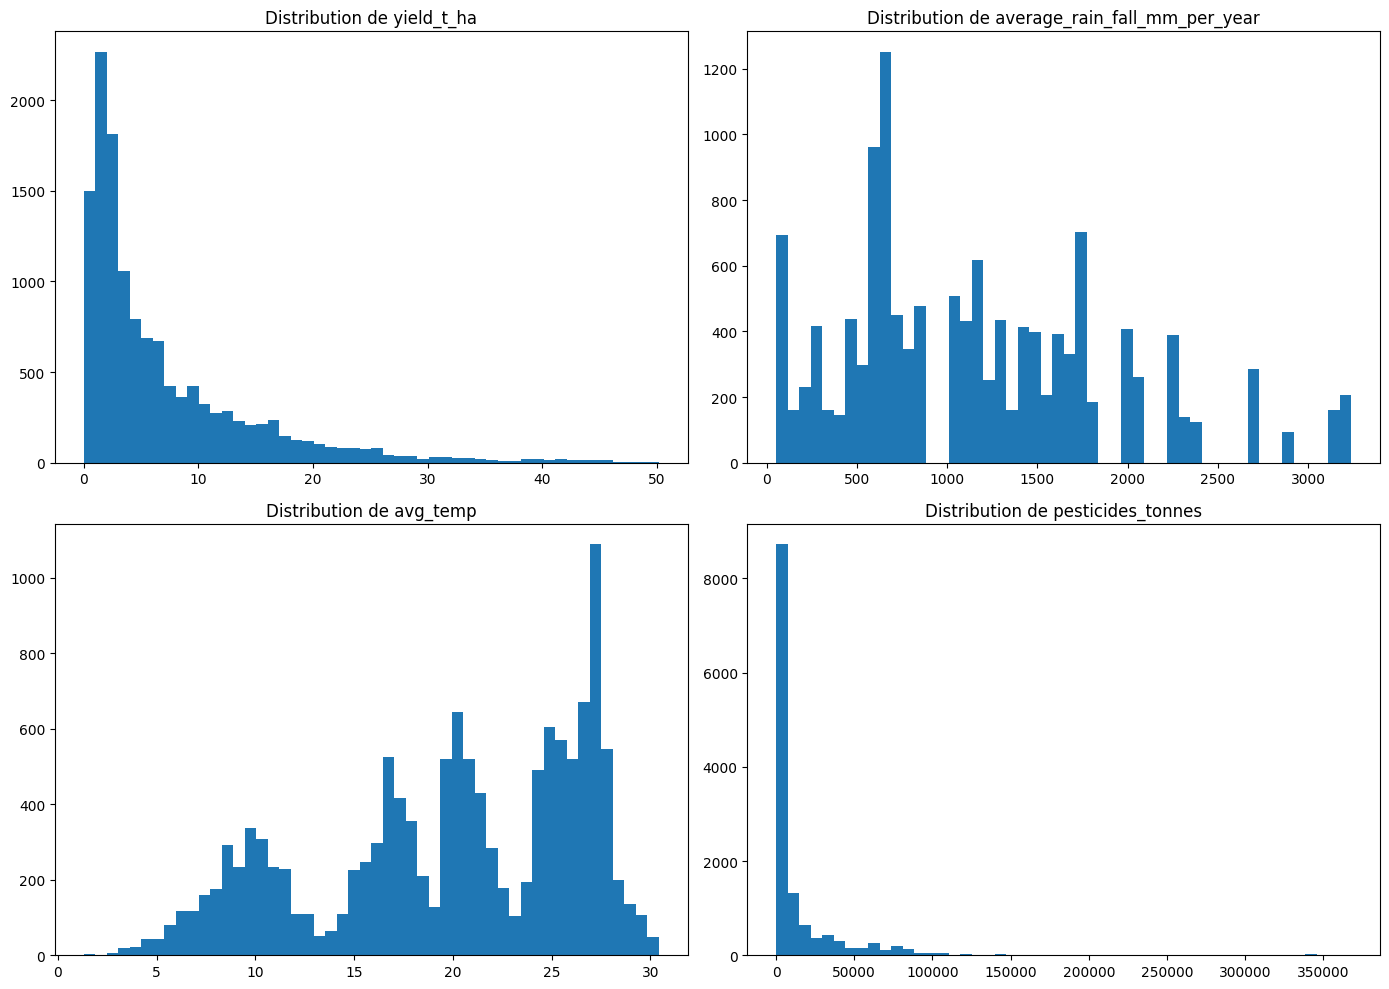

,count,mean,std,min,25%,50%,75%,max
pesticides_tonnes,13130.0,14838.697886,33652.454670,0.040000,264.530000,2172.200000,13335.220000,367778.000000
log1p_pesticides_tonnes,13130.0,7.474329,2.577593,0.039221,5.581728,7.683956,9.498239,12.815237


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df_model["yield_t_ha"], bins=50)
axes[0, 0].set_title("Distribution de yield_t_ha")

axes[0, 1].hist(df_model["average_rain_fall_mm_per_year"], bins=50)
axes[0, 1].set_title("Distribution de average_rain_fall_mm_per_year")

axes[1, 0].hist(df_model["avg_temp"], bins=50)
axes[1, 0].set_title("Distribution de avg_temp")

axes[1, 1].hist(df_model["pesticides_tonnes"], bins=50)
axes[1, 1].set_title("Distribution de pesticides_tonnes")

plt.tight_layout()
plt.show()

df_model[["pesticides_tonnes", "log1p_pesticides_tonnes"]].describe().T

In [8]:
def iqr_summary(series: pd.Series) -> dict:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask = (series < low) | (series > high)
    return {
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "low": low,
        "high": high,
        "n_outliers": int(mask.sum()),
        "pct_outliers": float(mask.mean()),
    }

outlier_report = pd.DataFrame({
    col: iqr_summary(df_model[col].dropna())
    for col in ["yield_t_ha", "average_rain_fall_mm_per_year", "avg_temp", "pesticides_tonnes"]
}).T

outlier_report

,q1,q3,iqr,low,high,n_outliers,pct_outliers
yield_t_ha,1.80,9.715225,7.915225,-10.072838,21.588062,814.0,0.061995
average_rain_fall_mm_per_year,608.00,1651.000000,1043.000000,-956.500000,3215.500000,207.0,0.015765
avg_temp,15.67,25.780000,10.110000,0.505000,40.945000,0.0,0.000000
pesticides_tonnes,264.53,13335.220000,13070.690000,-19341.505000,32941.255000,1936.0,0.147449


## 5. Support des cultures et des zones géographiques

Le modèle de recommandation doit éviter de s’appuyer sur des catégories trop peu représentées.
Des seuils simples de support sont donc appliqués pour :

- limiter les cultures trop rares ;
- limiter les zones très faiblement représentées ;
- réduire le risque de recommandations peu fiables.

Les seuils retenus ici sont :
- au moins `100` observations par culture ;
- au moins `50` observations par zone.

In [9]:
item_counts = (
    df_model["Item"]
    .value_counts()
    .rename_axis("Item")
    .reset_index(name="n_obs")
)

area_counts = (
    df_model["Area"]
    .value_counts()
    .rename_axis("Area")
    .reset_index(name="n_obs")
)

display(item_counts.head(20))
display(area_counts.head(20))

,Item,n_obs
0,Potatoes,2091
1,Maize,2028
2,Wheat,1810
3,"Rice, paddy",1502
4,Sorghum,1435
5,Soybeans,1242
6,Sweet potatoes,1163
7,Cassava,941
8,Plantains and others,464
9,Yams,454


,Area,n_obs
0,Cameroon,230
1,Kenya,230
2,Colombia,207
3,Brazil,207
4,Burundi,207
5,Peru,207
6,Rwanda,207
7,Mali,207
8,Uganda,207
9,Ecuador,207


In [10]:
MIN_ITEM_SUPPORT = 100
MIN_AREA_SUPPORT = 50

supported_items = set(item_counts.loc[item_counts["n_obs"] >= MIN_ITEM_SUPPORT, "Item"])
supported_areas = set(area_counts.loc[area_counts["n_obs"] >= MIN_AREA_SUPPORT, "Area"])

df_supported = df_model[
    df_model["Item"].isin(supported_items) &
    df_model["Area"].isin(supported_areas)
].copy()

print("Cultures retenues :", len(supported_items))
print("Zones retenues :", len(supported_areas))
print("Shape après filtre de support :", df_supported.shape)

Cultures retenues : 10
Zones retenues : 90
Shape après filtre de support : (12710, 10)


## 6. Définition des deux objectifs de modélisation

Deux jeux de variables sont distingués.

### A. Benchmark maximal

Ce premier jeu de variables sert à estimer la performance maximale accessible sur ce dataset.
Il inclut des variables non nécessairement disponibles en production :

- `Area`
- `Item`
- `Year`
- `average_rain_fall_mm_per_year`
- `avg_temp`
- `log1p_pesticides_tonnes`

### B. Modèle déployable

Ce second jeu de variables correspond à l’usage réel de `/recommend`.
Il ne conserve que des variables plausiblement disponibles au moment de la recommandation :

- `Area`
- `Item`
- `average_rain_fall_mm_per_year`
- `avg_temp`

In [11]:
target_col = "yield_t_ha"

benchmark_features = [
    "Area",
    "Item",
    "Year",
    "average_rain_fall_mm_per_year",
    "avg_temp",
    "log1p_pesticides_tonnes",
]

deploy_features = [
    "Area",
    "Item",
    "average_rain_fall_mm_per_year",
    "avg_temp",
]

benchmark_df = df_supported[benchmark_features + [target_col]].dropna().copy()
deploy_df = df_supported[deploy_features + [target_col]].dropna().copy()

print("Benchmark df :", benchmark_df.shape)
print("Deploy df :", deploy_df.shape)

Benchmark df : (12710, 7)
Deploy df : (12710, 5)


## 7. Split train / test et préprocessing

Une pipeline standard est utilisée :

- imputation médiane + standardisation pour les variables numériques ;
- imputation la plus fréquente + one-hot encoding pour les variables catégorielles.

Ce préprocessing est partagé par les différents modèles testés.

In [12]:
def split_xy(df_in: pd.DataFrame, features: list[str], target: str):
    X = df_in[features].copy()
    y = df_in[target].copy()
    return train_test_split(X, y, test_size=0.2, random_state=SEED)

X_train_b, X_test_b, y_train_b, y_test_b = split_xy(benchmark_df, benchmark_features, target_col)
X_train_d, X_test_d, y_train_d, y_test_d = split_xy(deploy_df, deploy_features, target_col)

print("Benchmark split :", X_train_b.shape, X_test_b.shape)
print("Deploy split :", X_train_d.shape, X_test_d.shape)

Benchmark split : (10168, 6) (2542, 6)
Deploy split : (10168, 4) (2542, 4)


In [13]:
def make_preprocessor(X: pd.DataFrame, force_dense: bool = False) -> ColumnTransformer:
    numeric_features = X.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=not force_dense
            ),
        ),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_features),
            ("cat", categorical_pipe, categorical_features),
        ],
        sparse_threshold=0 if force_dense else 0.3,
    )

## 8. Benchmark initial des modèles

La première question posée est la suivante :

> le dataset annexe permet-il de construire un modèle utile pour la recommandation ?

Le benchmark compare plusieurs familles de modèles sur :
- le jeu **benchmark maximal** ;
- le jeu **déployable**.

L’évaluation repose sur :
- RMSE ;
- MAE ;
- R².

In [14]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def evaluate_models(X_train, X_test, y_train, y_test, use_catboost=False):
    models = {
        "dummy_mean": DummyRegressor(strategy="mean"),
        "ridge": Ridge(alpha=1.0),
        "random_forest": RandomForestRegressor(
            n_estimators=200,
            random_state=SEED,
            n_jobs=-1,
        ),
        "hist_gb": HistGradientBoostingRegressor(
            random_state=SEED
        ),
    }

    if use_catboost and CATBOOST_AVAILABLE:
        models["catboost"] = CatBoostRegressor(
            verbose=0,
            random_state=SEED,
            allow_writing_files=False,
        )

    rows = []

    for name, model in models.items():
        force_dense = name == "hist_gb"
        preprocessor = make_preprocessor(X_train, force_dense=force_dense)

        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model),
        ])

        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)

        rows.append({
            "model": name,
            "rmse": rmse(y_test, preds),
            "mae": mean_absolute_error(y_test, preds),
            "r2": r2_score(y_test, preds),
        })

    return pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)

def log_benchmark_table_to_mlflow(
    results_df: pd.DataFrame,
    run_name: str,
    feature_set_name: str,
    features: list[str],
    target_col: str,
    target_unit: str = "t/ha",
):
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("feature_set_name", feature_set_name)
        mlflow.log_param("target_col", target_col)
        mlflow.log_param("target_unit", target_unit)
        mlflow.log_param("n_features", len(features))
        mlflow.log_param("features", ",".join(features))

        for _, row in results_df.iterrows():
            model_name = row["model"]
            mlflow.log_metric(f"{model_name}_rmse", float(row["rmse"]))
            mlflow.log_metric(f"{model_name}_mae", float(row["mae"]))
            mlflow.log_metric(f"{model_name}_r2", float(row["r2"]))

        csv_path = OUT_DIR / f"{run_name}_benchmark.csv"
        results_df.to_csv(csv_path, index=False)
        mlflow.log_artifact(str(csv_path))

In [15]:
results_benchmark = evaluate_models(
    X_train_b, X_test_b, y_train_b, y_test_b, use_catboost=True
)

results_deploy = evaluate_models(
    X_train_d, X_test_d, y_train_d, y_test_d, use_catboost=True
)

print("=== Benchmark maximal ===")
display(results_benchmark)

print("=== Modèle déployable ===")
display(results_deploy)

log_benchmark_table_to_mlflow(
    results_df=results_benchmark,
    run_name="model_2_benchmark_maximal",
    feature_set_name="benchmark_maximal",
    features=benchmark_features,
    target_col=target_col,
)

log_benchmark_table_to_mlflow(
    results_df=results_deploy,
    run_name="model_2_benchmark_deployable",
    feature_set_name="deployable",
    features=deploy_features,
    target_col=target_col,
)

=== Benchmark maximal ===


,model,rmse,mae,r2
0,random_forest,1.364921,0.673645,0.969021
1,catboost,1.613504,1.034676,0.956709
2,hist_gb,2.211901,1.414988,0.918645
3,ridge,4.206353,2.800310,0.705785
4,dummy_mean,7.754892,5.633514,-0.000010


=== Modèle déployable ===


,model,rmse,mae,r2
0,catboost,2.181257,1.289577,0.920884
1,random_forest,2.269827,1.142749,0.914328
2,hist_gb,2.511010,1.561445,0.895155
3,ridge,4.267604,2.858912,0.697155
4,dummy_mean,7.754892,5.633514,-0.000010


## 9. Sélection et tuning du meilleur modèle déployable

Le modèle retenu pour le déploiement doit être choisi selon deux critères :

1. la performance ;
2. la déployabilité.

Lorsque CatBoost est disponible, un grid search ciblé est lancé sur le jeu de variables déployable.
Dans le cas contraire, la baseline linéaire sert de repli explicite.

In [16]:
if CATBOOST_AVAILABLE:
    catboost_pipe = Pipeline([
        ("preprocessor", make_preprocessor(deploy_df[deploy_features])),
        ("model", CatBoostRegressor(
            random_state=SEED,
            verbose=0,
            allow_writing_files=False,
            thread_count=1,
        )),
    ])

    param_grid = {
        "model__depth": [4, 6, 8],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__iterations": [300, 500, 800],
        "model__l2_leaf_reg": [3, 5, 7],
    }

    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

    grid = GridSearchCV(
        estimator=catboost_pipe,
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )

    grid.fit(deploy_df[deploy_features], deploy_df[target_col])

    best_estimator = grid.best_estimator_
    best_params = grid.best_params_
    best_cv_rmse = -grid.best_score_

    print("Best params:", best_params)
    print("Best CV RMSE:", best_cv_rmse)

    with mlflow.start_run(run_name="model_2_catboost_gridsearch_deployable"):
        mlflow.log_param("model_name", "CatBoostRegressor")
        mlflow.log_param("feature_set_name", "deployable")
        mlflow.log_param("features", ",".join(deploy_features))
        mlflow.log_param("target_col", target_col)
        mlflow.log_param("target_unit", "t/ha")

        for k, v in best_params.items():
            mlflow.log_param(k, v)

        mlflow.log_metric("best_cv_rmse", float(best_cv_rmse))
        mlflow.sklearn.log_model(sk_model=best_estimator, artifact_path="model")
else:
    best_estimator = Pipeline([
        ("preprocessor", make_preprocessor(deploy_df[deploy_features])),
        ("model", Ridge(alpha=1.0)),
    ])
    best_params = {"model__name": "Ridge(alpha=1.0)"}
    best_cv_rmse = np.nan
    print("CatBoost indisponible : la baseline Ridge est conservée comme modèle déployable de repli.")

Fitting 5 folds for each of 81 candidates, totalling 405 fits


2026/04/01 00:23:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/01 00:23:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best params: {'model__depth': 8, 'model__iterations': 800, 'model__l2_leaf_reg': 7, 'model__learning_rate': 0.1}
Best CV RMSE: 2.177291703248291


2026/04/01 00:23:45 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


## 10. Validation croisée du meilleur modèle déployable

La stabilité du meilleur modèle déployable est vérifiée en validation croisée à 5 plis.
Cette étape fournit également une estimation exploitable de la marge d’erreur du modèle secondaire.

In [17]:
if CATBOOST_AVAILABLE:
    best_deploy_model = CatBoostRegressor(
        random_state=SEED,
        verbose=0,
        allow_writing_files=False,
        depth=best_params["model__depth"],
        learning_rate=best_params["model__learning_rate"],
        iterations=best_params["model__iterations"],
        l2_leaf_reg=best_params["model__l2_leaf_reg"],
    )
else:
    best_deploy_model = Ridge(alpha=1.0)

deploy_pipe = Pipeline([
    ("preprocessor", make_preprocessor(deploy_df[deploy_features], force_dense=False)),
    ("model", best_deploy_model),
])

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = cross_validate(
    deploy_pipe,
    deploy_df[deploy_features],
    deploy_df[target_col],
    cv=cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2",
    },
    n_jobs=-1,
)

cv_summary = {
    "rmse_mean": -cv_results["test_rmse"].mean(),
    "rmse_std": (-cv_results["test_rmse"]).std(),
    "mae_mean": -cv_results["test_mae"].mean(),
    "mae_std": (-cv_results["test_mae"]).std(),
    "r2_mean": cv_results["test_r2"].mean(),
    "r2_std": cv_results["test_r2"].std(),
}

cv_summary

{'rmse_mean': np.float64(2.177291703248291),
 'rmse_std': np.float64(0.12258737630420691),
 'mae_mean': np.float64(1.1997330092601188),
 'mae_std': np.float64(0.04388097526075749),
 'r2_mean': np.float64(0.9167365907216315),
 'r2_std': np.float64(0.006924371510720453)}

In [18]:
with mlflow.start_run(run_name="model_2_cv_deployable_best"):
    mlflow.log_param("feature_set_name", "deployable")
    mlflow.log_param("target_col", target_col)
    mlflow.log_param("target_unit", "t/ha")
    mlflow.log_param("features", ",".join(deploy_features))
    mlflow.log_param("model_name", type(best_deploy_model).__name__)

    for k, v in best_params.items():
        mlflow.log_param(k, v)

    for k, v in cv_summary.items():
        mlflow.log_metric(k, float(v))

## 11. Entraînement final et export des artefacts

Le modèle secondaire est réentraîné sur l’ensemble du dataset déployable, puis exporté avec ses métadonnées.
Les métadonnées incluent :

- les variables utilisées ;
- les cultures et zones supportées ;
- les niveaux de support observés ;
- une référence climatique moyenne par zone ;
- une marge d’erreur issue de la validation croisée.

In [19]:
final_reco_model = Pipeline([
    ("preprocessor", make_preprocessor(deploy_df[deploy_features], force_dense=False)),
    ("model", best_deploy_model),
])

final_reco_model.fit(deploy_df[deploy_features], deploy_df[target_col])

artifacts_dir = ROOT / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

item_support_map = item_counts.set_index("Item")["n_obs"].to_dict()

area_climate_reference_df = (
    df_model.groupby("Area", as_index=False)
    .agg(
        average_rain_fall_mm_per_year=("average_rain_fall_mm_per_year", "mean"),
        avg_temp=("avg_temp", "mean"),
    )
)

area_climate_reference = {
    row["Area"]: {
        "rainfall_mm": float(row["average_rain_fall_mm_per_year"]),
        "temperature_celsius": float(row["avg_temp"]),
    }
    for _, row in area_climate_reference_df.iterrows()
}

model_2_meta = {
    "target": target_col,
    "target_unit": "t/ha",
    "features": deploy_features,
    "model_name": type(best_deploy_model).__name__,
    "best_params": best_params,
    "supported_items_count": len(supported_items),
    "supported_areas_count": len(supported_areas),
    "supported_items": sorted(supported_items),
    "supported_areas": sorted(supported_areas),
    "item_support_counts": item_support_map,
    "error_margin_t_ha": cv_summary["rmse_mean"],
    "cv_summary": cv_summary,
    "area_climate_reference": area_climate_reference,
    "note": "Modèle 2 orienté recommandation de cultures à partir du dataset annexe consolidé.",
}

joblib.dump(final_reco_model, artifacts_dir / "model_2_recommendation.joblib")

with open(artifacts_dir / "model_2_meta.json", "w", encoding="utf-8") as f:
    json.dump(model_2_meta, f, indent=2, ensure_ascii=False)

print("Artefacts exportés dans :", artifacts_dir)

Artefacts exportés dans : C:\Users\thoma\Documents\Openclassroom\Projet-12\artifacts


In [20]:
with mlflow.start_run(run_name="model_2_final_deployable_best"):
    mlflow.log_param("feature_set_name", "deployable")
    mlflow.log_param("target_col", target_col)
    mlflow.log_param("target_unit", "t/ha")
    mlflow.log_param("features", ",".join(deploy_features))
    mlflow.log_param("model_name", type(best_deploy_model).__name__)

    for k, v in best_params.items():
        mlflow.log_param(k, v)

    for k, v in cv_summary.items():
        mlflow.log_metric(k, float(v))

    mlflow.sklearn.log_model(sk_model=final_reco_model, artifact_path="model")
    mlflow.log_artifact(str(artifacts_dir / "model_2_meta.json"))

2026/04/01 00:23:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/01 00:23:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/01 00:23:57 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


## 12. Prototype de logique de recommandation

La recommandation repose sur le principe suivant :

1. une ligne candidate est générée pour chaque culture supportée ;
2. le modèle prédit le rendement attendu dans les conditions fournies ;
3. les cultures sont triées selon le rendement prédit ;
4. un niveau de confiance simple est ajouté à partir du support observé.

Cette logique constitue la base de l’endpoint `/recommend`.

In [21]:
def support_to_confidence(n_obs: int) -> str:
    if n_obs >= 1000:
        return "high"
    if n_obs >= 300:
        return "medium"
    return "low"

def recommend_crops(area: str, rainfall: float, temperature: float, top_k: int = 5):
    candidate_items = sorted(supported_items)

    candidates = pd.DataFrame({
        "Area": [area] * len(candidate_items),
        "Item": candidate_items,
        "average_rain_fall_mm_per_year": [rainfall] * len(candidate_items),
        "avg_temp": [temperature] * len(candidate_items),
    })

    preds = final_reco_model.predict(candidates)

    reco = candidates[["Item"]].copy()
    reco["predicted_yield_t_ha"] = preds
    reco["support_n"] = reco["Item"].map(item_support_map)
    reco["confidence"] = reco["support_n"].map(support_to_confidence)

    return (
        reco.sort_values("predicted_yield_t_ha", ascending=False)
        .head(top_k)
        .reset_index(drop=True)
    )

In [22]:
recommend_crops(
    area="India",
    rainfall=1200,
    temperature=24,
    top_k=5,
)

,Item,predicted_yield_t_ha,support_n,confidence
0,Cassava,22.715575,941,medium
1,Potatoes,13.011034,2091,high
2,Yams,6.891340,454,medium
3,Sweet potatoes,6.221717,1163,high
4,Plantains and others,5.924453,464,medium


## Conclusion opérationnelle

Le dataset annexe permet de construire un **modèle secondaire utile pour la recommandation**.
Le modèle retenu n’a pas vocation à remplacer le modèle principal, mais à compléter le routage applicatif lorsque la couverture du modèle 1 est insuffisante.

Les résultats de ce notebook alimentent directement :

- l’artefact `model_2_recommendation.joblib` ;
- les métadonnées `model_2_meta.json` ;
- la logique de classement des cultures dans `/recommend`.